Final Weights: [-1.00000000e-01  1.11022302e-16]
Final Bias: 0.4


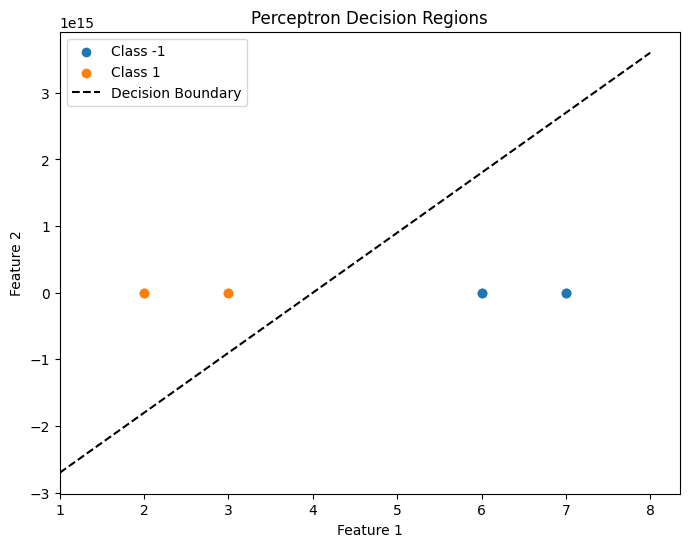

In [2]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [2, 3],
    [3, 3],
    [2, 4],
    [3, 4],
    [6, 7],
    [7, 7],
    [6, 8],
    [7, 8]
])

# Labels: +1 and -1
y = np.array([1, 1, 1, 1, -1, -1, -1, -1])

class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=50):
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for _ in range(self.epochs):
            for i in range(len(X)):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = 1 if linear_output >= 0 else -1

                # Perceptron Learning Rule
                if y[i] * linear_output <= 0:
                    self.weights += self.lr * y[i] * X[i]
                    self.bias += self.lr * y[i]

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, -1)


model = Perceptron(learning_rate=0.1, epochs=100)
model.fit(X, y)

print("Final Weights:", model.weights)
print("Final Bias:", model.bias)

def plot_decision_regions(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.1),
        np.arange(y_min, y_max, 0.1)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    predictions = model.predict(grid)
    predictions = predictions.reshape(xx.shape)

    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, predictions, alpha=0.3)

    # Plot actual points
    for label in np.unique(y):
        plt.scatter(
            X[y == label, 0],
            X[y == label, 1],
            label=f"Class {label}"
        )

    x_values = np.linspace(x_min, x_max, 100)
    y_values = -(model.weights[0] * x_values + model.bias) / model.weights[1]
    plt.plot(x_values, y_values, 'k--', label="Decision Boundary")

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Perceptron Decision Regions")
    plt.legend()
    plt.show()


plot_decision_regions(X, y, model)
